In [ ]:
import json, re, collections, statistics, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.facecolor'] = '#0f1829'
plt.rcParams['axes.facecolor']   = '#162035'
plt.rcParams['axes.edgecolor']   = '#1e2d45'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['axes.labelcolor']  = '#94a3b8'
plt.rcParams['xtick.color']      = '#94a3b8'
plt.rcParams['ytick.color']      = '#94a3b8'
plt.rcParams['grid.color']       = '#1e2d45'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['font.family']      = 'monospace'
ACCENT = ['#00d4ff','#7c3aed','#10b981','#f59e0b','#ef4444','#ec4899','#6366f1','#14b8a6','#84cc16','#f97316']

FILE = 'metagenomics_instruction.jsonl'


✅ Libraries loaded


## 1. Load Raw Data

In [8]:
raw = []
parse_errors = 0
with open(FILE, encoding='utf-8') as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line: continue
        try:
            raw.append(json.loads(line))
        except json.JSONDecodeError as e:
            parse_errors += 1

print(f'Total lines read   : {i:,}')
print(f'Successfully parsed: {len(raw):,}')
print(f'Parse errors       : {parse_errors}')
print(f'\nFirst record keys  : {list(raw[0].keys()) if raw else "N/A"}')
print('\nSample record:')
print(json.dumps(raw[0], indent=2)[:500] if raw else 'N/A')

Total lines read   : 4,483
Successfully parsed: 4,483
Parse errors       : 0

First record keys  : ['instruction', 'input', 'output']

Sample record:
{
  "instruction": "HOW do gut microbiota\u2011derived metabolites enhance poultry innate resistance while supporting productivity?",
  "input": "",
  "output": "Gut microbiota produce short\u2011chain fatty acids, bile acid derivatives, and amino\u2011acid catabolites that act as signalling molecules for avian immune cells. These metabolites modulate metabolic pathways such as glycolysis and fatty\u2011acid oxidation, promoting rapid proliferation and activation of macrophages, T cells, and inn


## 2. Cleaning Pipeline

In [9]:
def clean_text(t):
    if not t: return ''
    t = t.replace('\u200b','').replace('\xa0',' ')
    t = re.sub(r'\s+', ' ', t).strip()
    return t

cleaned = []
removed_reasons = collections.Counter()
seen_instructions = set()

for r in raw:
    inst = clean_text(r.get('instruction',''))
    inp  = clean_text(r.get('input',''))
    out  = clean_text(r.get('output',''))

    if not inst:
        removed_reasons['missing_instruction'] += 1; continue
    if not out:
        removed_reasons['missing_output'] += 1; continue
    if len(out.split()) < 10:
        removed_reasons['output_too_short (<10w)'] += 1; continue
    if len(inst.split()) < 4:
        removed_reasons['instruction_too_short (<4w)'] += 1; continue

    key = re.sub(r'\W+','', inst.lower())[:60]
    if key in seen_instructions:
        removed_reasons['duplicate'] += 1; continue
    seen_instructions.add(key)

    cleaned.append({'instruction': inst, 'input': inp, 'output': out})

df = pd.DataFrame(cleaned)
print(f'Before cleaning : {len(raw):,}')
print(f'After cleaning  : {len(df):,}')
print(f'Removed         : {len(raw) - len(df):,}')
print(f'\nRemoval reasons:')
for k,v in removed_reasons.items():
    print(f'  {k:40s}: {v}')

Before cleaning : 4,483
After cleaning  : 4,467
Removed         : 16

Removal reasons:
  duplicate                               : 16


## 3. Basic Statistics

In [10]:
df['inst_words']  = df['instruction'].apply(lambda x: len(x.split()))
df['input_words'] = df['input'].apply(lambda x: len(x.split()) if x else 0)
df['out_words']   = df['output'].apply(lambda x: len(x.split()))
df['has_input']   = df['input'].apply(lambda x: bool(x.strip()))

print('=== INSTRUCTION STATS ===')
print(df['inst_words'].describe().to_string())
print('\n=== OUTPUT STATS ===')
print(df['out_words'].describe().to_string())
print(f'\nRecords WITH non-empty input : {df["has_input"].sum():,} ({df["has_input"].mean()*100:.1f}%)')
print(f'Records with EMPTY input     : {(~df["has_input"]).sum():,} ({(~df["has_input"]).mean()*100:.1f}%)')

=== INSTRUCTION STATS ===
count    4467.000000
mean       15.177748
std         3.845158
min         6.000000
25%        12.000000
50%        15.000000
75%        18.000000
max        34.000000

=== OUTPUT STATS ===
count    4467.000000
mean       71.859861
std        13.972017
min        25.000000
25%        62.000000
50%        71.000000
75%        81.000000
max       134.000000

Records WITH non-empty input : 0 (0.0%)
Records with EMPTY input     : 4,467 (100.0%)


## 4. Word Count Distributions

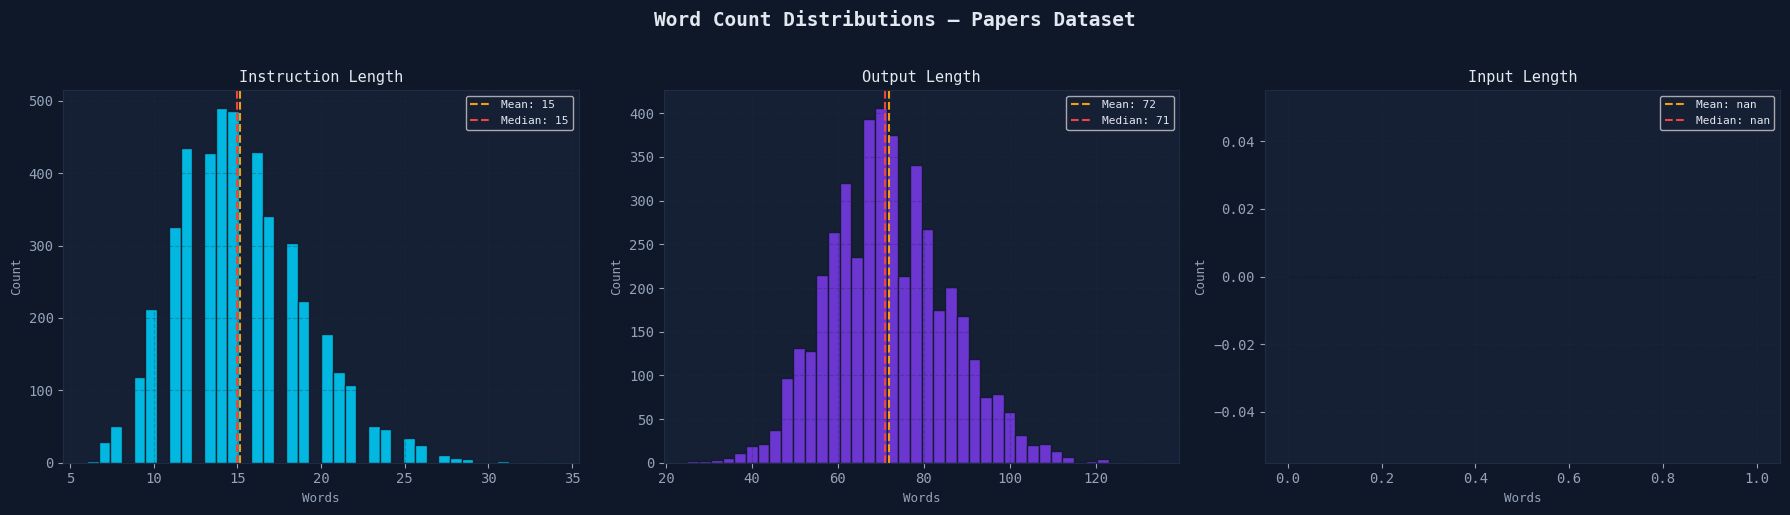

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1829')
fig.suptitle('Word Count Distributions — Papers Dataset', color='#e2e8f0', fontsize=14, fontweight='bold', y=1.02)

for ax, col, color, title in zip(
    axes,
    ['inst_words', 'out_words', 'input_words'],
    ['#00d4ff', '#7c3aed', '#10b981'],
    ['Instruction Length', 'Output Length', 'Input Length']
):
    data = df[col][df[col] > 0]
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='#0f1829')
    ax.set_title(title, color='#e2e8f0', fontsize=11)
    ax.set_xlabel('Words', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.axvline(data.mean(), color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='#ef4444', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('papers_word_dist.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()

## 5. Question Type Analysis

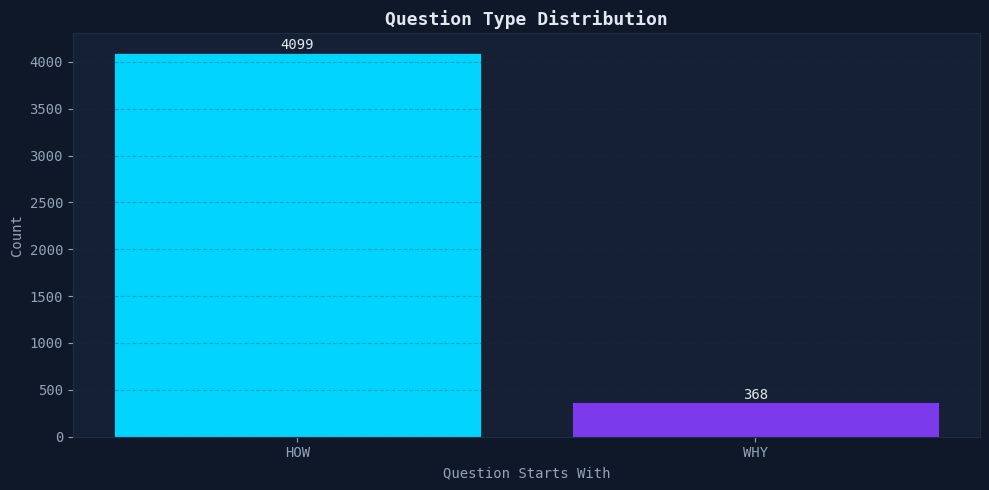

qtype
HOW    4099
WHY     368


In [12]:
def get_qtype(inst):
    w = inst.strip().upper()
    for q in ['HOW','WHAT','WHY','WHEN','WHERE','WHICH','CAN','IS','DOES','DO']:
        if w.startswith(q): return q
    return 'OTHER'

df['qtype'] = df['instruction'].apply(get_qtype)
qtype_counts = df['qtype'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1829')
bars = ax.bar(qtype_counts.index, qtype_counts.values, color=ACCENT[:len(qtype_counts)], edgecolor='#0f1829', linewidth=0.5)
ax.set_title('Question Type Distribution', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Question Starts With', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
for bar, val in zip(bars, qtype_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', va='bottom', color='#e2e8f0', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('papers_qtypes.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()
print(qtype_counts.to_string())

## 6. Topic / Category Detection

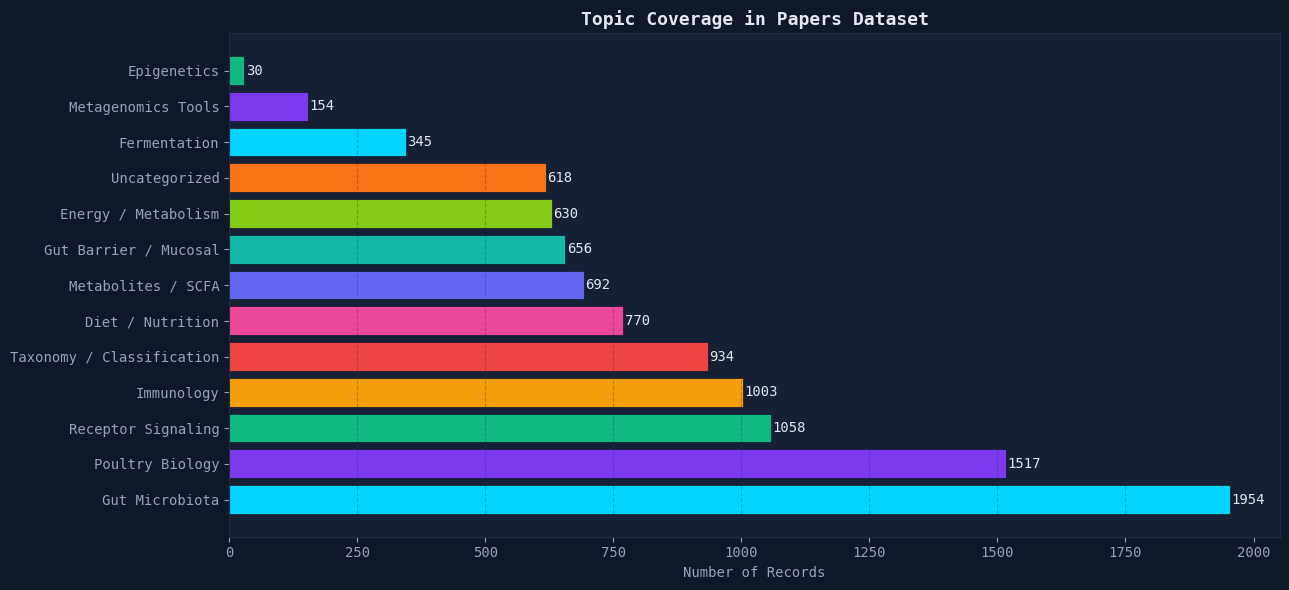


Topic Distribution:
  Gut Microbiota                     :  1954  (43.7%)
  Poultry Biology                    :  1517  (34.0%)
  Receptor Signaling                 :  1058  (23.7%)
  Immunology                         :  1003  (22.5%)
  Taxonomy / Classification          :   934  (20.9%)
  Diet / Nutrition                   :   770  (17.2%)
  Metabolites / SCFA                 :   692  (15.5%)
  Gut Barrier / Mucosal              :   656  (14.7%)
  Energy / Metabolism                :   630  (14.1%)
  Uncategorized                      :   618  (13.8%)
  Fermentation                       :   345  (7.7%)
  Metagenomics Tools                 :   154  (3.4%)
  Epigenetics                        :    30  (0.7%)


In [13]:
TOPICS = {
    'Gut Microbiota':          ['microbiota','microbiome','microbial','gut bacteria','microorganism'],
    'Metabolites / SCFA':      ['metabolite','short-chain','fatty acid','scfa','butyrate','propionate','acetate','indole'],
    'Immunology':              ['immune','immunometabol','cytokine','inflammatory','macrophage','t cell','lymphocyte','innate'],
    'Receptor Signaling':      ['receptor','signaling','gpr41','gpr43','fxr','tgr5','toll-like','cascade','pathway','kinase'],
    'Gut Barrier / Mucosal':   ['barrier','mucosal','epithelial','tight junction','mucus','intestinal','permeability'],
    'Diet / Nutrition':        ['diet','nutrition','feed','fiber','substrate','polyphenol','amino acid','carbohydrate'],
    'Poultry Biology':         ['poultry','avian','bird','chicken','broiler','turkey','hen','flock'],
    'Fermentation':            ['ferment','anaerobic','lactic acid','bifidobacterium','lactobacillus','clostridium'],
    'Metagenomics Tools':      ['metaspades','fastqc','checkm','maxbin','trimmomatic','fastp','bowtie','kraken','assembly','binning','contig'],
    'Epigenetics':             ['epigenetic','histone','deacetylase','methylation','chromatin'],
    'Energy / Metabolism':     ['glycolysis','oxidative','atp','energy','mitochondria','metabolic pathway','lipid'],
    'Taxonomy / Classification':['taxonomy','16s','phylogenetic','species','genus','classification','otu','asv'],
}

def detect_topics(text, topic_dict):
    text = text.lower()
    found = []
    for topic, kws in topic_dict.items():
        if any(kw in text for kw in kws):
            found.append(topic)
    return found if found else ['Uncategorized']

df['topics'] = df.apply(lambda r: detect_topics(r['instruction'] + ' ' + r['output'], TOPICS), axis=1)
df['topic_count'] = df['topics'].apply(len)

# Flatten for counting
all_topics = [t for topics in df['topics'] for t in topics]
topic_counts = collections.Counter(all_topics)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1829')
topics_sorted = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)
labels, vals = zip(*topics_sorted)
colors = ACCENT[:len(labels)]
bars = ax.barh(labels, vals, color=colors, edgecolor='#0f1829', linewidth=0.5)
ax.set_title('Topic Coverage in Papers Dataset', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records', fontsize=10)
for bar, val in zip(bars, vals):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', color='#e2e8f0', fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('papers_topics.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()

print('\nTopic Distribution:')
for label, val in topics_sorted:
    pct = val / len(df) * 100
    print(f'  {label:35s}: {val:5d}  ({pct:.1f}%)')

## 7. Bash / Code Detection

Records with bash/code in OUTPUT : 96 (2.1%)
Records with bash/code in INPUT  : 0 (0.0%)
Records FULLY conceptual (no code): 4,371 (97.9%)


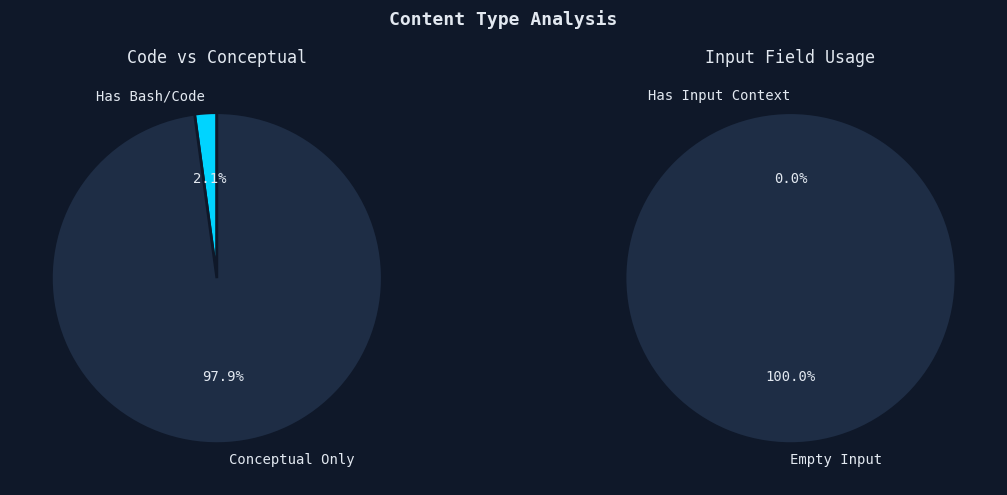

In [14]:
BASH_PATTERN = re.compile(
    r'(fastqc|trimmomatic|metaspades|spades|maxbin|checkm|fastp|bowtie|samtools'
    r'|kraken|micromamba|conda|bash|mkdir|chmod|python |import |\$\s|\./|'
    r'\.sh\b|\.py\b|--\w+|-[a-z]\s|/usr|/home|/tmp|/data)',
    re.IGNORECASE
)

df['has_bash']     = df['output'].apply(lambda x: bool(BASH_PATTERN.search(x)))
df['has_bash_inp'] = df['input'].apply(lambda x: bool(BASH_PATTERN.search(x)))

bash_pct = df['has_bash'].mean() * 100
print(f'Records with bash/code in OUTPUT : {df["has_bash"].sum():,} ({bash_pct:.1f}%)')
print(f'Records with bash/code in INPUT  : {df["has_bash_inp"].sum():,} ({df["has_bash_inp"].mean()*100:.1f}%)')
print(f'Records FULLY conceptual (no code): {(~df["has_bash"]).sum():,} ({(~df["has_bash"]).mean()*100:.1f}%)')

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f1829')

# Bash presence
axes[0].pie(
    [df['has_bash'].sum(), (~df['has_bash']).sum()],
    labels=['Has Bash/Code', 'Conceptual Only'],
    colors=['#00d4ff','#1e2d45'], autopct='%1.1f%%', startangle=90,
    textprops={'color':'#e2e8f0'}, wedgeprops={'edgecolor':'#0f1829','linewidth':2}
)
axes[0].set_title('Code vs Conceptual', color='#e2e8f0', fontsize=12)

# Input presence
axes[1].pie(
    [df['has_input'].sum(), (~df['has_input']).sum()],
    labels=['Has Input Context', 'Empty Input'],
    colors=['#10b981','#1e2d45'], autopct='%1.1f%%', startangle=90,
    textprops={'color':'#e2e8f0'}, wedgeprops={'edgecolor':'#0f1829','linewidth':2}
)
axes[1].set_title('Input Field Usage', color='#e2e8f0', fontsize=12)

plt.suptitle('Content Type Analysis', color='#e2e8f0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('papers_content_type.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()

## 8. Most Frequent Keywords

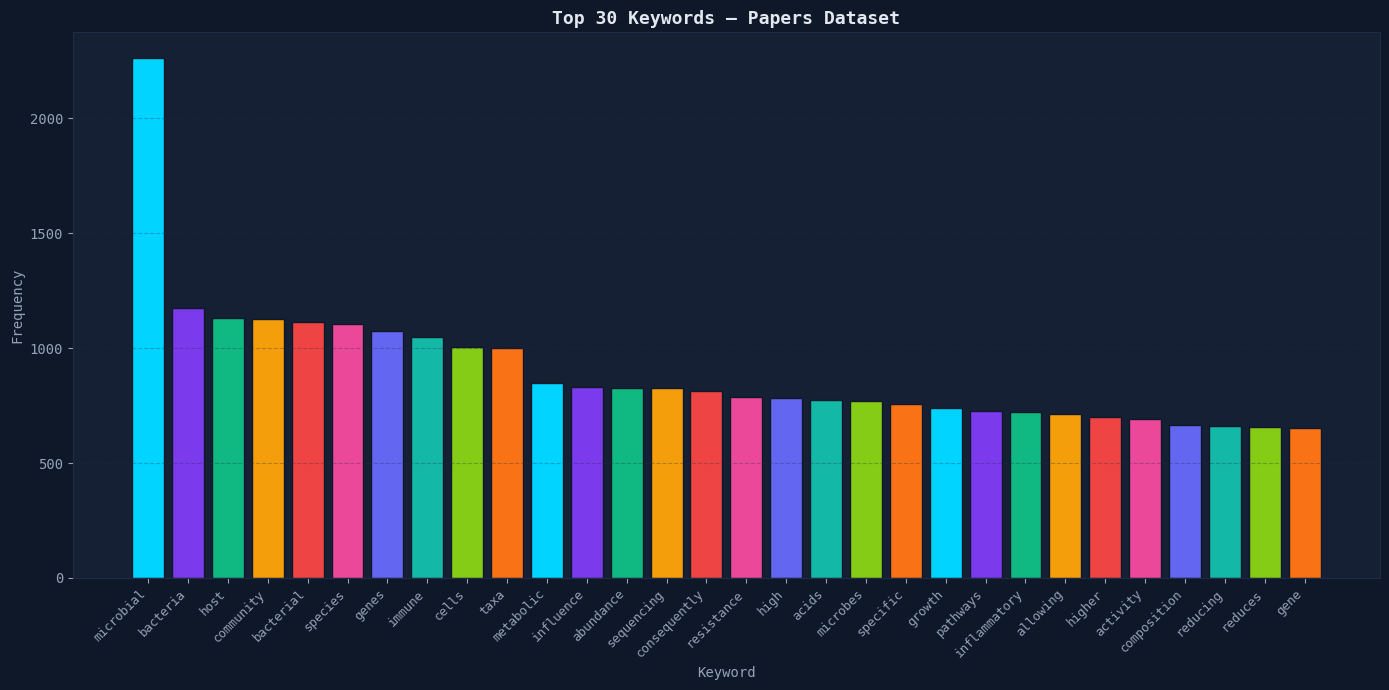

In [15]:
STOPWORDS = set(['the','a','an','of','in','to','and','is','are','that','this','for',
                 'with','on','by','as','at','be','it','its','from','or','which','can',
                 'also','these','their','they','them','not','into','how','do','does',
                 'what','why','when','where','such','both','through','between','while',
                 'well','more','have','has','had','been','during','was','were','will',
                 'would','could','should','may','might','thus','than','each','other',
                 'same','overall','result','results','include','including','production'])

all_words = []
for r in cleaned:
    text = (r['instruction'] + ' ' + r['output']).lower()
    words = re.findall(r'\b[a-z]{4,}\b', text)
    all_words.extend([w for w in words if w not in STOPWORDS])

word_freq = collections.Counter(all_words).most_common(30)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f1829')
colors = [ACCENT[i % len(ACCENT)] for i in range(len(words))]
bars = ax.bar(words, freqs, color=colors, edgecolor='#0f1829')
ax.set_title('Top 30 Keywords — Papers Dataset', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Keyword', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('papers_keywords.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()

## 9. Output Length Buckets

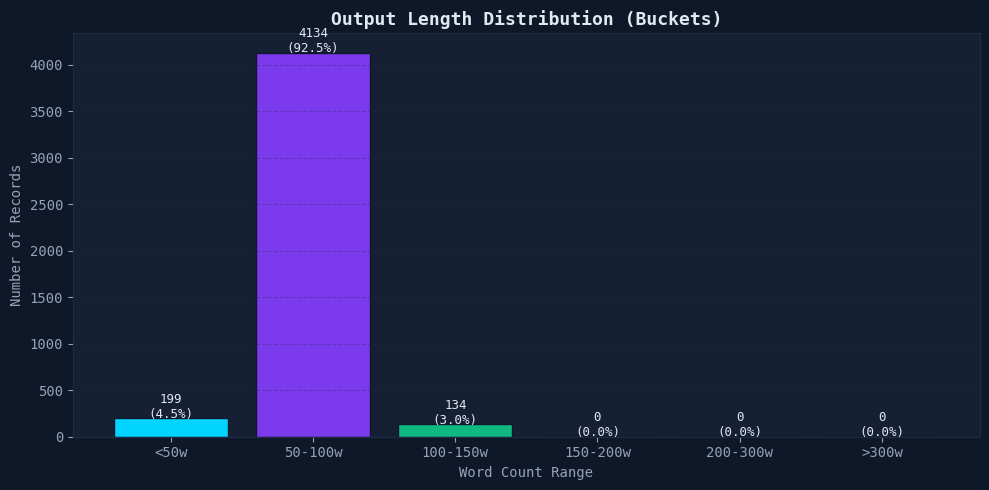

In [16]:
bins_labels = ['<50w', '50-100w', '100-150w', '150-200w', '200-300w', '>300w']
bins_ranges = [(0,50),(50,100),(100,150),(150,200),(200,300),(300,9999)]
bin_counts = []
for lo, hi in bins_ranges:
    c = ((df['out_words'] >= lo) & (df['out_words'] < hi)).sum()
    bin_counts.append(c)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1829')
bars = ax.bar(bins_labels, bin_counts, color=ACCENT[:6], edgecolor='#0f1829')
ax.set_title('Output Length Distribution (Buckets)', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count Range', fontsize=10)
ax.set_ylabel('Number of Records', fontsize=10)
for bar, val in zip(bars, bin_counts):
    pct = val/len(df)*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val}\n({pct:.1f}%)', ha='center', color='#e2e8f0', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('papers_outlen_buckets.png', dpi=130, bbox_inches='tight', facecolor='#0f1829')
plt.show()

## 10. Final KPI Summary

In [17]:
print('='*55)
print('   PAPERS DATASET — FINAL KPI SUMMARY')
print('='*55)
print(f'  Total records (raw)          : {len(raw):,}')
print(f'  After cleaning               : {len(df):,}')
print(f'  Removed                      : {len(raw)-len(df):,} ({(len(raw)-len(df))/len(raw)*100:.1f}%)')
print(f'  Duplicates removed           : {removed_reasons["duplicate"]}')
print()
print(f'  Avg instruction length       : {df["inst_words"].mean():.1f} words')
print(f'  Avg output length            : {df["out_words"].mean():.1f} words')
print(f'  Median output length         : {df["out_words"].median():.1f} words')
print()
print(f'  Records with empty input     : {(~df["has_input"]).sum():,} ({(~df["has_input"]).mean()*100:.1f}%)')
print(f'  Records with bash/code       : {df["has_bash"].sum():,} ({df["has_bash"].mean()*100:.1f}%)')
print()
print('  Top 5 topics:')
for label, val in topics_sorted[:5]:
    print(f'    {label:35s}: {val:5d} ({val/len(df)*100:.1f}%)')
print()
print('  ⚠  GAPS IDENTIFIED:')
print(f'    → {(~df["has_bash"]).mean()*100:.1f}% records have NO bash commands')
print(f'    → {(~df["has_input"]).mean()*100:.1f}% records have EMPTY input field')
top_topic = topics_sorted[0][0]
top_pct = topics_sorted[0][1]/len(df)*100
print(f'    → Dominant topic: "{top_topic}" ({top_pct:.1f}%) — not metagenomics tools')
print(f'    → "Metagenomics Tools" records: {topic_counts.get("Metagenomics Tools",0)} ({topic_counts.get("Metagenomics Tools",0)/len(df)*100:.1f}%)')
print('='*55)

   PAPERS DATASET — FINAL KPI SUMMARY
  Total records (raw)          : 4,483
  After cleaning               : 4,467
  Removed                      : 16 (0.4%)
  Duplicates removed           : 16

  Avg instruction length       : 15.2 words
  Avg output length            : 71.9 words
  Median output length         : 71.0 words

  Records with empty input     : 4,467 (100.0%)
  Records with bash/code       : 96 (2.1%)

  Top 5 topics:
    Gut Microbiota                     :  1954 (43.7%)
    Poultry Biology                    :  1517 (34.0%)
    Receptor Signaling                 :  1058 (23.7%)
    Immunology                         :  1003 (22.5%)
    Taxonomy / Classification          :   934 (20.9%)

  ⚠  GAPS IDENTIFIED:
    → 97.9% records have NO bash commands
    → 100.0% records have EMPTY input field
    → Dominant topic: "Gut Microbiota" (43.7%) — not metagenomics tools
    → "Metagenomics Tools" records: 154 (3.4%)


## 11. Export Cleaned Dataset

In [20]:

TOPICS_GARDER = {
    'Metagenomics Tools',
    'Taxonomy / Classification',
    'Gut Microbiota',
    'Fermentation',
    'Energy / Metabolism',
    'Epigenetics'
}

TOPICS_SUPPRIMER = {
    'Poultry Biology',
    'Receptor Signaling',
    'Gut Barrier / Mucosal',
    'Immunology',
    'Diet / Nutrition',
    'Uncategorized'
}

cleaned_filtered = []
for r in cleaned:
    text = (r['instruction'] + ' ' + r['output']).lower()
    topics_found = [
        topic for topic, kws in TOPICS.items()
        if any(kw in text for kw in kws)
    ]
    # Garder si au moins un topic utile est présent
    if any(t in TOPICS_GARDER for t in topics_found):
        cleaned_filtered.append(r)

print(f"Avant filtre domaine : {len(cleaned):,}")
print(f"Après filtre domaine : {len(cleaned_filtered):,}")
print(f"Supprimés hors sujet : {len(cleaned) - len(cleaned_filtered):,}")

Avant filtre domaine : 4,467
Après filtre domaine : 2,822
Supprimés hors sujet : 1,645


In [ ]:

final_records = []
for r in cleaned_filtered:
    final_records.append({
        "input":  r["instruction"],
        "output": r["output"]
    })

out_path_final = "papers_final.jsonl"
with open(out_path_final, "w", encoding="utf-8") as f:
    for r in final_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"Dataset final sauvegardé : {out_path_final}")
print(f"   Records utiles           : {len(final_records):,}")
print(f"   Réduction totale         : {len(raw) - len(final_records):,} records supprimés")
print(f"   Taux de rétention        : {len(final_records)/len(raw)*100:.1f}%")
print(f"\nSample record:")
print(json.dumps(final_records[0], indent=2))

✅ Dataset final sauvegardé : papers_final.jsonl
   Records utiles           : 2,822
   Réduction totale         : 1,661 records supprimés
   Taux de rétention        : 62.9%

Sample record:
{
  "input": "HOW do gut microbiota\u2011derived metabolites enhance poultry innate resistance while supporting productivity?",
  "output": "Gut microbiota produce short\u2011chain fatty acids, bile acid derivatives, and amino\u2011acid catabolites that act as signalling molecules for avian immune cells. These metabolites modulate metabolic pathways such as glycolysis and fatty\u2011acid oxidation, promoting rapid proliferation and activation of macrophages, T cells, and innate lymphoid cells. By shifting immune cell metabolism, the bird mounts a faster and more efficient defense against pathogens, reducing disease incidence. Simultaneously, these metabolites improve nutrient absorption and feed\u2011conversion efficiency, preserving overall productivity."
}


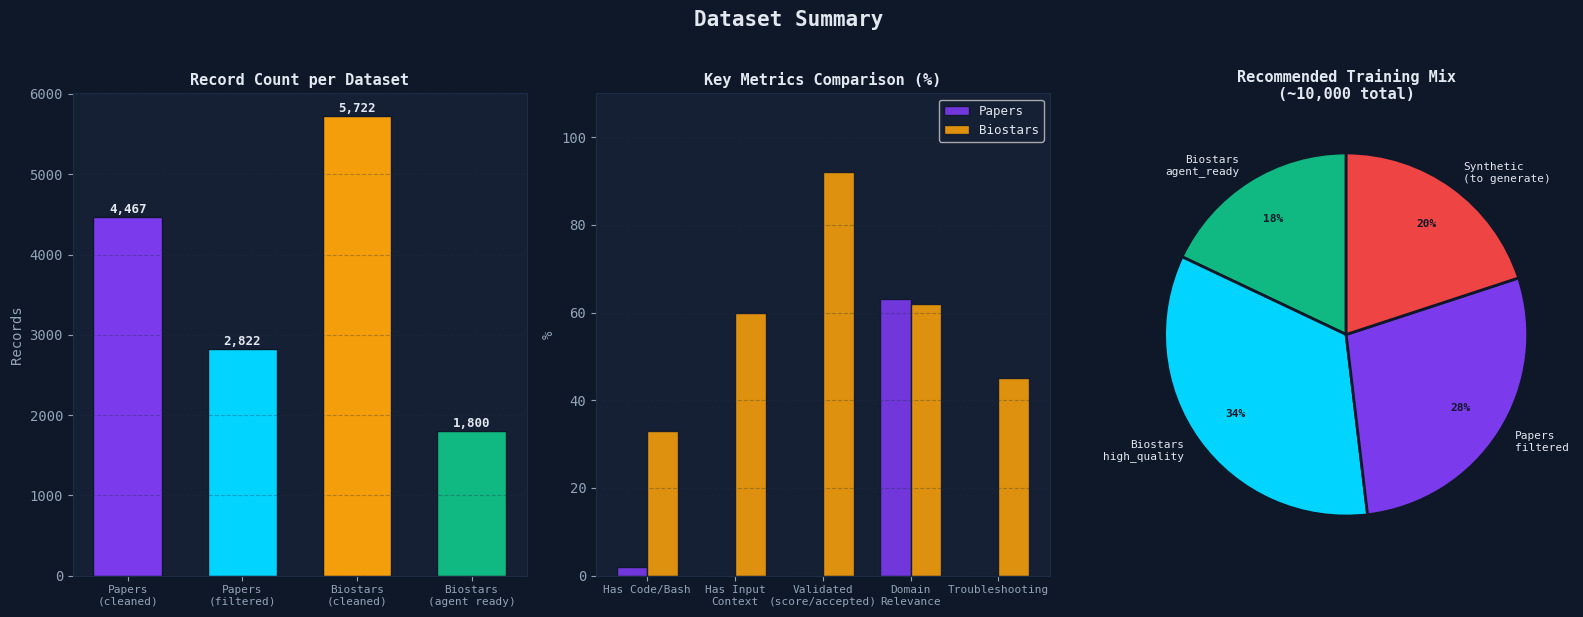

✅ genomeer_dataset_summary.png saved


In [23]:
# ── Cellule : Visualisation synthétique finale — 2 datasets ──

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f1829')
fig.suptitle('Dataset Summary ', 
             color='#e2e8f0', fontsize=15, fontweight='bold', y=1.02)

# ── 1. Volume comparison ──
datasets     = ['Papers\n(cleaned)', 'Papers\n(filtered)', 
                'Biostars\n(cleaned)', 'Biostars\n(agent ready)']
values       = [4467, 2822, 5722, 1800]
bar_colors   = ['#7c3aed','#00d4ff','#f59e0b','#10b981']

bars = axes[0].bar(datasets, values, color=bar_colors, edgecolor='#0f1829', width=0.6)
axes[0].set_title('Record Count per Dataset', color='#e2e8f0', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Records', color='#94a3b8')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{val:,}', ha='center', color='#e2e8f0', fontsize=9, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)
plt.setp(axes[0].get_xticklabels(), fontsize=8)

# ── 2. Key metrics radar-style bar ──
metrics      = ['Has Code/Bash', 'Has Input\nContext', 'Validated\n(score/accepted)', 
                'Domain\nRelevance', 'Troubleshooting']
papers_vals  = [2,   0,  0,  63, 0 ]
biostars_vals= [33,  60, 92, 62, 45]

x = range(len(metrics))
w = 0.35
axes[1].bar([i - w/2 for i in x], papers_vals,   width=w, color='#7c3aed', 
            label='Papers',   edgecolor='#0f1829', alpha=0.9)
axes[1].bar([i + w/2 for i in x], biostars_vals, width=w, color='#f59e0b', 
            label='Biostars', edgecolor='#0f1829', alpha=0.9)
axes[1].set_title('Key Metrics Comparison (%)', color='#e2e8f0', fontsize=11, fontweight='bold')
axes[1].set_ylabel('%', color='#94a3b8')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics, fontsize=8)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9, facecolor='#162035', labelcolor='#e2e8f0')
axes[1].grid(True, axis='y', alpha=0.3)

# ── 3. Final training mix donut ──
mix_labels = ['Biostars\nagent_ready', 'Biostars\nhigh_quality', 
              'Papers\nfiltered', 'Synthetic\n(to generate)']
mix_vals   = [1800, 3400, 2822, 2000]
mix_colors = ['#10b981','#00d4ff','#7c3aed','#ef4444']
wedges, texts, autotexts = axes[2].pie(
    mix_vals,
    labels=mix_labels,
    colors=mix_colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'#0f1829','linewidth':2},
    textprops={'color':'#e2e8f0','fontsize':8}
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('#0f1829')
    at.set_fontweight('bold')
axes[2].set_title('Recommended Training Mix\n(~10,000 total)', 
                  color='#e2e8f0', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('genomeer_dataset_summary.png', dpi=150, 
            bbox_inches='tight', facecolor='#0f1829')
plt.show()
print("✅ genomeer_dataset_summary.png saved")

### Rapport — Papers Dataset (papers_final.jsonl)

#Volume : 4,483 raw → 4,467 après déduplication → 2,822 records finaux (62.9% rétention, 1,661 supprimés)
Structure : Format input/output uniquement, 0 erreurs de parsing, 100% input non-vide après reformatage.
Longueur : Instructions ~15 mots avg, outputs ~72 mots avg, 92.5% des outputs dans le range 50-100 mots. Distribution très homogène (std=14).
Types de questions : HOW 91.7% (4,099), WHY 8.2% (368). Zéro diversité de type.
Code/Bash : 2.1% seulement (96 records). Dataset 97.9% conceptuel.
Topics retenus : Gut Microbiota 43.7% · Taxonomy/Classification 20.9% · Fermentation 7.7% · Metagenomics Tools 3.4% · Energy/Metabolism 14.1%

Supprimé (37.1%) : Records exclusivement Poultry Biology, Receptor Signaling moléculaire pur, Immunologie cellulaire sans lien computationnel — trop spécifiques à la biologie animale, aucune valeur pour un agent bash.
Gardé (62.9%) : Tout ce qui touche au microbiome, taxonomie, fermentation, outils — constitue la base de connaissance biologique du LLM.
Verdict : Dataset utile uniquement comme couche conceptuelle (comprendre le domaine). Insuffisant seul pour fine-tuner un agent — 0 input context, 2.1% code. Doit être combiné avec Biostars pour les commandes réelles.